#  Hungarian dataset - Data Exploration

In [1]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import data_path, week_numbers

---

# Potentials
- Generators
- Storages

In [2]:
potentials_generator = pd.read_excel(data_path, sheet_name='potentials_generator', index_col=0, na_values='None')
technologies_generator = potentials_generator.keys().to_numpy()
potentials_generator

,Solar,Wind Offshore,Wind Onshore,Hydro Run-of-river,Hydro Water Reservoir,Geothermal,Biomass,Waste,Fossil Lignite,Fossil Hard coal,Fossil Gas,Nuclear,Fusion
p_nom,4000.00,0.00,1500.0,30.0,25.0,0.0,500.00,300.00,600.00,0.00,1900.00,2000.000,100.000
p_nom_max,6000.00,0.00,2000.0,36.0,28.0,0.0,600.00,300.00,600.00,0.00,2500.00,4000.000,1000.000
p_nom_min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1800.000,NaN
up,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.000,0.000
down,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.000,0.000
ramp_up,0.75,0.25,1.0,1.0,1.0,1.0,0.01,0.01,0.01,0.01,0.01,0.005,0.005
ramp_down,0.75,0.25,1.0,1.0,1.0,1.0,0.01,0.01,0.01,0.01,0.01,0.005,0.005


In [3]:
potentials_storage = pd.read_excel(data_path, sheet_name='potentials_storage', index_col=0, na_values='None')
technologies_storage = potentials_storage.keys().to_numpy()
potentials_storage	

,Pumped Storage Actual,Storage Actual
p_nom_max,2500,0
up,0,0
down,0,0


# Cost
- `c1`: Capital cost [€/MW/28n] (once per power plant)
- `c2`: Operation cost [€/MWh]
- `c3`: Environment and CO$_2$ [€/MWh]
- `c4`: Risk [€/MWh]
- `c5`: Reliability [€/MWh]

In [4]:
costs_generator = pd.read_excel(data_path, sheet_name='costs_generator', index_col=0,na_values='None')
costs_generator

,Solar,Wind Offshore,Wind Onshore,Hydro Run-of-river,Hydro Water Reservoir,Geothermal,Biomass,Waste,Fossil Lignite,Fossil Hard coal,Fossil Gas,Nuclear,Fusion
capital,2958.861261,7832.279809,4525.317223,7582.746532,10110.328710,13053.799682,7796.409521,8425.273925,7796.409521,7796.409521,5221.519873,13568.077146,17136.154293
operation,0.695652,1.565217,1.304348,0.834783,0.834783,1.739130,30.703288,0.000000,26.086957,26.086957,50.869565,7.826087,7.043478
environment,0.029459,0.023190,0.023190,0.023513,0.023513,0.021519,0.049154,0.065035,0.194088,0.193973,0.165463,0.051582,0.022863
risk,0.000268,0.006699,0.006699,0.022098,0.022098,0.011256,0.010130,0.009005,0.023325,0.068480,0.097517,0.112540,0.021104
reliability,0.159462,0.124622,0.138469,0.092852,0.030197,0.049930,0.057433,0.057433,0.057433,0.057433,0.015745,0.078866,0.049930
start_up,NaN,NaN,NaN,NaN,NaN,NaN,0.000100,0.000100,NaN,NaN,NaN,NaN,NaN
shut_down,NaN,NaN,NaN,NaN,NaN,NaN,0.000100,0.000100,NaN,NaN,NaN,NaN,NaN


In [5]:
costs_storage = pd.read_excel(data_path, sheet_name='costs_storage', index_col=0, na_values='None')
costs_storage

,Pumped Storage Actual,Storage Actual
capital,3072.017467,7796.262038
operation,0.000000,0.000000
environment,0.000000,0.000000
risk,0.000000,0.000000
reliability,0.000000,0.000000
start_up,0.000100,NaN
shut_down,0.000100,NaN


# Wind and PV profiles

- week **15**: middle of **April**
- week **28**: beginning of **July**
- week **40**: end of September / beginning of **October**
- week **49**: beggining of **December**

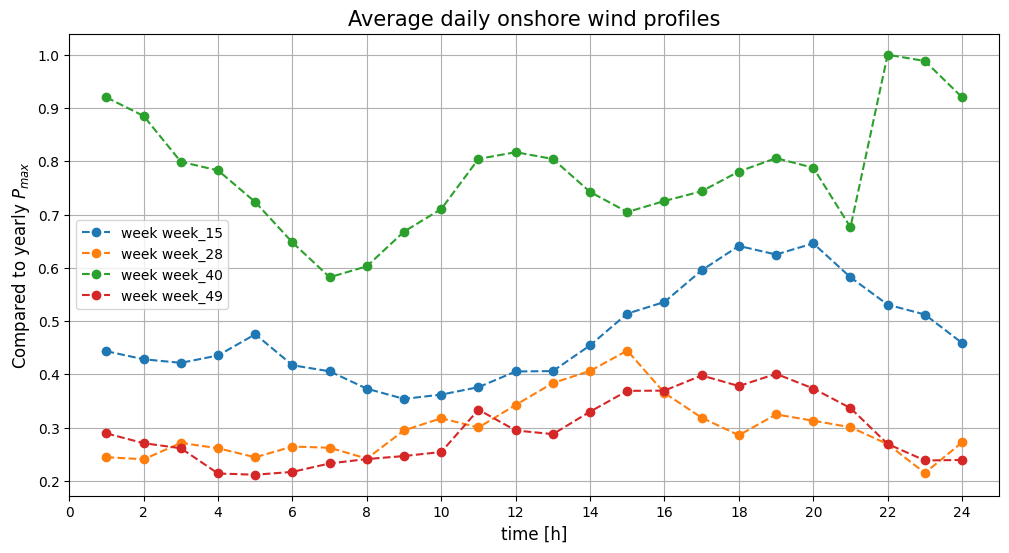

In [6]:
profile_wind = pd.read_excel(data_path, sheet_name='profile_wind', 
                             names=list(week_numbers.keys()), header=None, index_col=0)

plt.figure(figsize=(12,6))
for week_num in profile_wind.columns.values:
    plt.plot(profile_wind[week_num], 'o--', label=f'week {week_num}')
plt.xlim(0,25)
plt.xticks(np.arange(0,25,2))
plt.title('Average daily onshore wind profiles', fontsize=15)
plt.xlabel('time [h]', fontsize=12)
plt.ylabel(r'Compared to yearly $P_{max}$', fontsize=12)
plt.legend()
plt.grid()

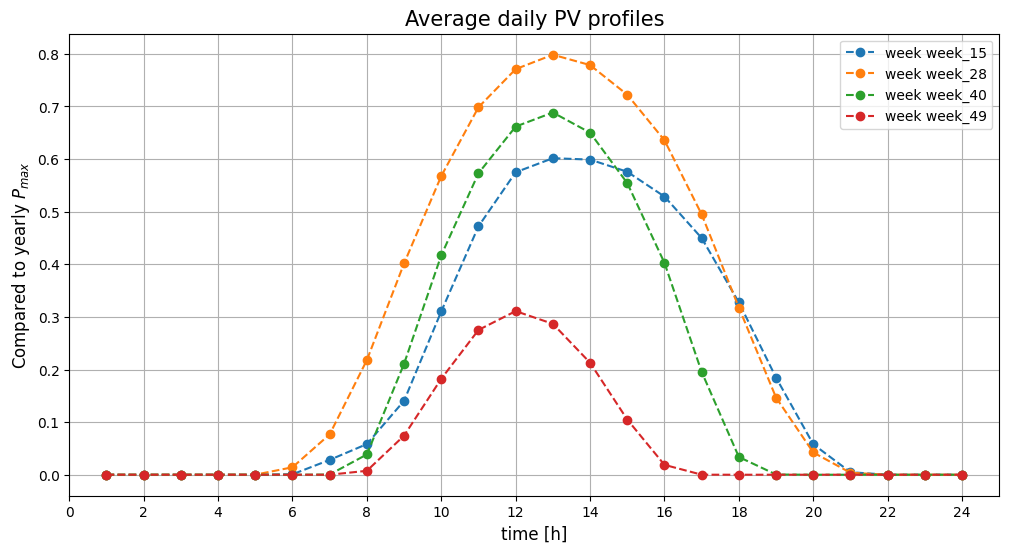

In [7]:
profile_PV = pd.read_excel(data_path, sheet_name='profile_PV', 
                           names=list(week_numbers.keys()), header=None, index_col=0)

plt.figure(figsize=(12,6))
for week_num in profile_PV.columns.values:
    plt.plot(profile_PV[week_num], 'o--', label=f'week {week_num}')
plt.xlim(0,25)
plt.xticks(np.arange(0,25,2))
plt.title('Average daily PV profiles', fontsize=15)
plt.xlabel('time [h]', fontsize=12)
plt.ylabel(r'Compared to yearly $P_{max}$', fontsize=12)
plt.legend()
plt.grid()

missing value interpolation: 
```python
profile_PV['15'].interpolate(method='cubic')[profile_PV['15'].isna()].values[0]
```

# Electric Demand

Electric demand [MWh] in Hungary across 4 weeeks (4*7 days) in hourly resolution.

In [8]:
demand = pd.DataFrame()
demand_df = pd.read_excel(data_path, sheet_name='demand').values.ravel() 
for i, week in enumerate(week_numbers.keys()):
	demand[week] = demand_df[i*len(demand_df)//4:(i+1)*len(demand_df)//4]

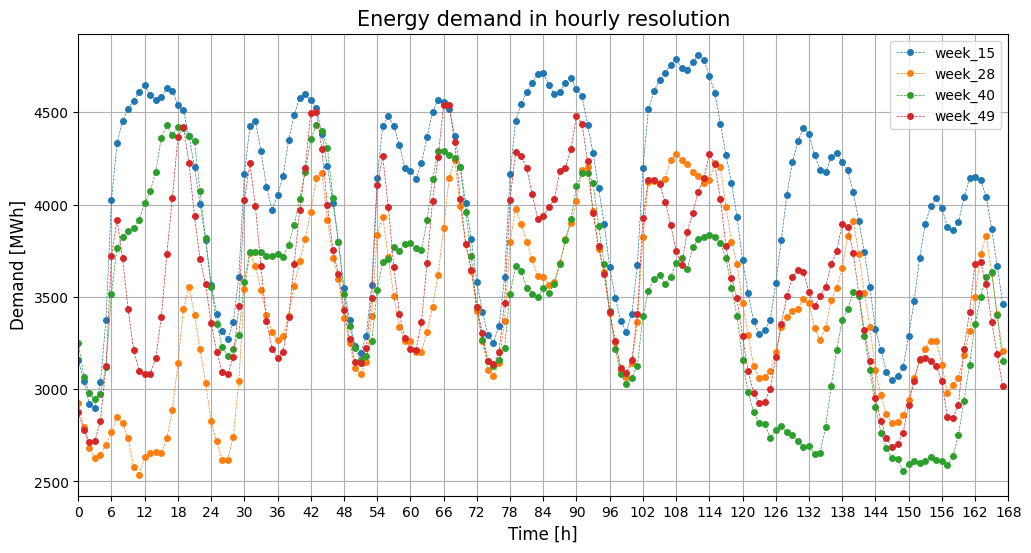

In [9]:
plt.figure(figsize=(12,6))
for week in demand.columns:
	plt.plot(demand[week], 'o--', ms=4, lw=0.5, label=week)
plt.title('Energy demand in hourly resolution', fontsize=15)
plt.xlabel('Time [h]', fontsize=12)
plt.ylabel('Demand [MWh]', fontsize=12)
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks(np.arange(0, len(demand)+1, 24//4))
plt.xlim(0, len(demand))
plt.grid()
plt.show()